# 04 — Random Forest
Walk-forward Random Forest on weekly silver log-returns with lagged features.
Same train/val/test split and evaluation metrics as the ARIMA, LSTM, and XGBoost notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [ ]:
# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)

TARGET       = 'silver_return'
EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
                'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level feature — separate group for ablation (see §8)
EXOG         = EXOG_RETURNS + EXOG_LEVELS

# Base weekly matrix: target + cross-asset returns + gs_ratio_z. The frame is un-lagged
# (build_features applies the 1-week lag); the W-FRI aggregation lives in 02_features.
base_cols = [TARGET] + EXOG_RETURNS + EXOG_LEVELS
all_w   = weekly[base_cols].dropna().copy()
n_train = int((weekly.loc[all_w.index, 'split'] != 'test').sum())

print(f'Weekly obs — train+val: {n_train}, test: {len(all_w) - n_train}')
print(f'Features available: {[c for c in EXOG if c in all_w.columns]}')

Weekly obs — train+val: 417, test: 174
Features available: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z']


## 2. Feature matrix

Each row is week $t$; all features use week $t-1$ values — no lookahead.

**Base features (always included):**
- `{exog}_lag1`: last week's return for each cross-asset (gold, USD, copper, S&P500, VIX, oil)
- `gs_ratio_z_lag1`: gold/silver ratio z-score at last Friday close, using train-period
  mean/std (a mean-reversion signal; see `02_features.ipynb` for derivation)
- `silver_lag1/2/3`: silver autocorrelation signal

**Technical extras** (selected by RF importance in `02c_technical_features_weekly.ipynb`):
- `macd_line`, `macd_hist`, `bb_bandwidth`, `silver_vol_5w` — pre-lagged by 1 week when joined to `all_w`

In [3]:
def build_features(df):
    """Baseline EXOG feature matrix — returns-only.
    gs_ratio_z is NOT included here so the baseline ARIMAX/EXOG variant is a
    pure 'returns + silver lags' model. gs_ratio_z is added in the +GS variants
    via the variants comparison cell (see §8)."""
    X = pd.DataFrame(index=df.index)
    for col in [c for c in EXOG_RETURNS if c in df.columns]:
        X[f'{col}_lag1'] = df[col].shift(1)
    for lag in [1, 2, 3]:
        X[f'silver_lag{lag}'] = df[TARGET].shift(lag)
    return X

features_all = build_features(all_w)
feature_cols = features_all.columns.tolist()
print('Baseline EXOG features:', feature_cols)

Baseline EXOG features: ['gold_return_lag1', 'usd_return_lag1', 'copper_return_lag1', 'sp500_return_lag1', 'vix_return_lag1', 'oil_return_lag1', 'silver_lag1', 'silver_lag2', 'silver_lag3']


## 3. Hyperparameter tuning with TimeSeriesSplit

Grid search on the training set only using 5-fold time-series cross-validation.
`TimeSeriesSplit` always trains on past data and validates on future data — no lookahead.

In [4]:
X_tr = features_all.iloc[:n_train][feature_cols].values
y_tr = all_w[TARGET].iloc[:n_train].values

mask = ~np.isnan(X_tr).any(axis=1)
X_tr, y_tr = X_tr[mask], y_tr[mask]

param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [6, 8, None],   # None = fully grown trees (RF default)
    'min_samples_leaf': [3, 5, 10],
    'max_features':   ['sqrt', 0.7],
}

tscv = TimeSeriesSplit(n_splits=5)
best_rmse, best_params = np.inf, {}

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Searching {len(combos)} combinations...')

for combo in combos:
    params = dict(zip(keys, combo))
    fold_rmses = []
    for fold_tr, fold_val in tscv.split(X_tr):
        m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        m.fit(X_tr[fold_tr], y_tr[fold_tr])
        preds = m.predict(X_tr[fold_val])
        fold_rmses.append(np.sqrt(mean_squared_error(y_tr[fold_val], preds)))
    rmse = np.mean(fold_rmses)
    if rmse < best_rmse:
        best_rmse, best_params = rmse, params

print(f'Best CV RMSE: {best_rmse:.5f}')
print(f'Best params:  {best_params}')

Searching 36 combinations...


Best CV RMSE: 0.03841
Best params:  {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


## 4. Walk-forward forecast

Retrains every 4 weeks (monthly) rather than every week — RF with 200 trees changes
negligibly from one extra observation, so weekly retraining is just wasted compute.

In [5]:
def walk_forward(all_w, features_all, n_train, feature_cols,
                 retrain_every=4, window=None, **rf_kwargs):
    """window=None → expanding; window=N → rolling (last N weeks)."""
    y_all = all_w[TARGET].values
    X_all = features_all[feature_cols].values
    preds = np.full(len(all_w) - n_train, np.nan)
    model = None

    for i, t in enumerate(range(n_train, len(all_w))):
        start = max(0, t - window) if window else 0
        X_tr  = X_all[start:t]
        y_tr  = y_all[start:t]
        X_te  = X_all[t:t+1]
        mask  = ~np.isnan(X_tr).any(axis=1)
        if mask.sum() < 10 or np.isnan(X_te).any():
            continue
        if model is None or i % retrain_every == 0:
            model = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_kwargs)
            model.fit(X_tr[mask], y_tr[mask])
        preds[i] = model.predict(X_te)[0]

    return preds

print('Running walk-forward Random Forest — expanding window...')
preds_rf_exp = walk_forward(all_w, features_all, n_train, feature_cols, **best_params)
print('Running walk-forward Random Forest — rolling window (100 weeks)...')
preds_rf_rol = walk_forward(all_w, features_all, n_train, feature_cols, window=100, **best_params)
print('Done')
preds_rf = preds_rf_exp  # default used downstream

Running walk-forward Random Forest — expanding window...


Running walk-forward Random Forest — rolling window (100 weeks)...


Done


## 5. Evaluate

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

y_test     = all_w[TARGET].iloc[n_train:].values
test_index = all_w.index[n_train:]

naive_pred = all_w[TARGET].iloc[n_train-1:-1].values

metrics = []
metrics.append(evaluate('Naive (t-1 week)',    y_test[1:], naive_pred[1:]))
metrics.append(evaluate('RF expanding',        y_test, preds_rf_exp))
metrics.append(evaluate('RF rolling (100w)',   y_test, preds_rf_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_rf.csv', index=False)
metrics_df

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
RF expanding                                   RMSE=0.05359  MAE=0.03765  DA=0.511  WDA=0.484
RF rolling (100w)                              RMSE=0.05385  MAE=0.03842  DA=0.494  WDA=0.488


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,0.491329,0.489862
1,RF expanding,0.053587,0.037649,0.511494,0.484237
2,RF rolling (100w),0.053853,0.038422,0.494253,0.488067


## 6. Predicted vs actual

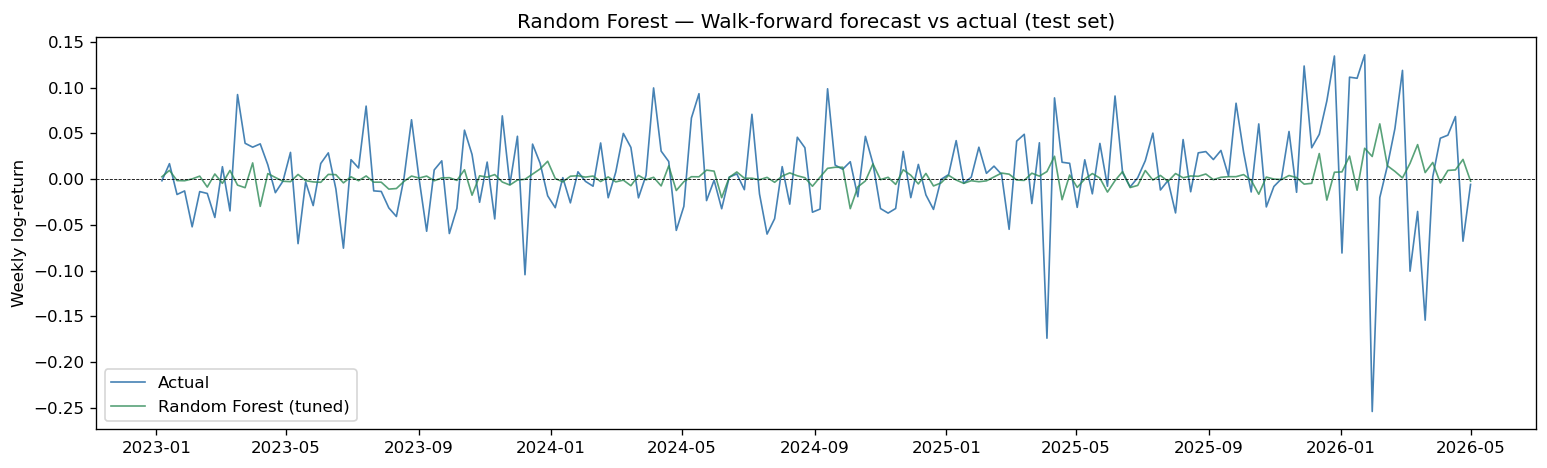

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test,  lw=1, label='Actual',               color='steelblue')
ax.plot(test_index, preds_rf, lw=1, label='Random Forest (tuned)', color='seagreen', alpha=0.8)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Random Forest — Walk-forward forecast vs actual (test set)')
ax.set_ylabel('Weekly log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature importance

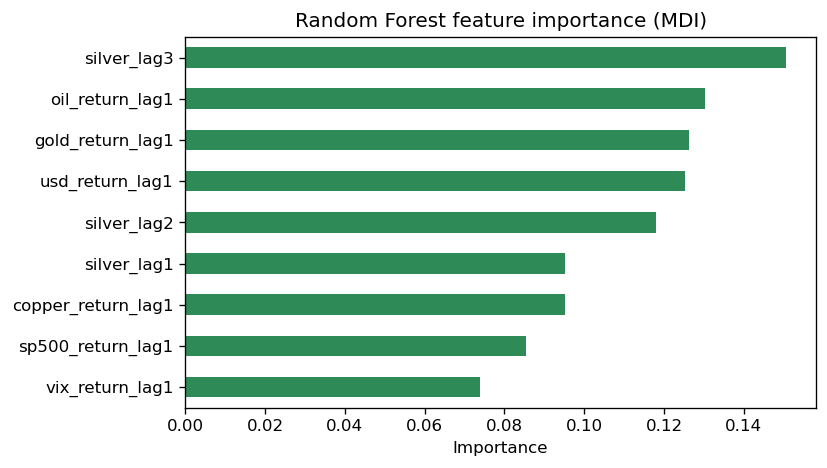

silver_lag3           0.150532
oil_return_lag1       0.130193
gold_return_lag1      0.126361
usd_return_lag1       0.125249
silver_lag2           0.118087
silver_lag1           0.095222
copper_return_lag1    0.095119
sp500_return_lag1     0.085369
vix_return_lag1       0.073868
dtype: float64


In [8]:
X_all = features_all[feature_cols].values
y_all = all_w[TARGET].values
mask  = ~np.isnan(X_all[:n_train]).any(axis=1)

final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
final_model.fit(X_all[:n_train][mask], y_all[:n_train][mask])

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='seagreen')
ax.set_title('Random Forest feature importance (MDI)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

## 8. Variants comparison

Re-runs the walk-forward Random Forest with different feature sets to test which
information sources improve out-of-sample performance.

`EXOG` = silver autocorrelation lags + 6 cross-asset lagged returns (gold, USD,
copper, S&P500, VIX, oil). `Tech` = silver lags + 4 tech indicators (no cross-assets).
A silver-lags-only model is omitted here because the AR information set is already
covered by the ARIMA baseline.

**Nonlinear features (NonLin).** Squared lagged returns — `silver_lag{k}²` for each
silver lag and `{exog}_lag1²` for each cross-asset. These capture **magnitude /
volatility** information independent of sign, motivated by ARCH-style volatility
clustering and the well-known leverage effect (large negative returns tend to be
followed by larger volatility). Trees can in principle approximate `x²` via
recursive splits, but each split has a cost in depth; explicit squared features
can help when the signal is weak relative to noise (as here). The `EXOG+NonLin`
variant lets the DM test directly answer whether volatility-style features add
predictive content beyond the linear EXOG base.

**Monthly macro (Macro).** The `EXOG+Macro` variant adds the four monthly macro
series (CPI, federal funds rate, industrial production, real rates) as raw lagged
weekly columns — 3 monthly lags each — produced in `02_features` §8 (MACRO group).
Unlike the linear MIDAS model (notebook 03), the random forest is handed the raw
lags directly: a tree ensemble learns its own lag weighting, so the MIDAS
Beta/Almon weight polynomial is unnecessary here. The macro columns are
publication-lag corrected and position-time aligned — see `03_midas.ipynb` §3 for
the look-ahead rationale.

**Daily-FRED changes & COT positioning (FRED_daily, COT).** Two further public-information
groups, mirroring the new ARIMA ablation ladder (`01_arima` §7) and read from the same
`feature_groups.json`. **FRED_daily** = Δ 10y real rate, Δ 10y breakeven, Δlog initial
jobless claims (summed weekly — changes are additive). **COT** = Managed-Money and
Commercial net positioning as % of open interest (Friday close, `.last()`). Both lagged 1
week. Each is a semi-strong-form-efficiency test: does the hard-data macro / positioning
channel beat the returns-only EXOG base?

| Variant | Features |
|---|---|
| Tech | Silver lags + MACD line, MACD histogram, Bollinger bandwidth, 5-week silver vol |
| EXOG | Silver lags + 6 cross-asset returns (baseline) |
| EXOG+NonLin | EXOG + squared silver lags + squared cross-asset returns |
| EXOG+Tech | EXOG + tech indicators |
| EXOG+Macro | EXOG + monthly macro lags (CPI, fed funds, ind. production, real rates × 3) |
| EXOG+FRED_daily | EXOG + daily-FRED changes (Δ 10y real rate, Δ breakeven, Δlog jobless claims) |
| EXOG+COT | EXOG + COT positioning (Managed-Money & Commercial net %) |
| EXOG+FRED_daily+COT | EXOG + daily-FRED + COT (hard macro + positioning bundle) |
| EXOG+Reddit | EXOG + Reddit sentiment (lag 1) |
| EXOG+News | EXOG + GDELT news sentiment (lag 1) |
| EXOG+Reddit+News | EXOG + Reddit + news sentiment |
| EXOG+Tech+Sentiment | EXOG + tech + Reddit + news sentiment |

Each variant re-tunes hyperparameters on its own feature set before walk-forward
and is evaluated on DA and WDA against the EXOG baseline. The best variant
by WDA feeds the sub-period breakdown and the 2026 zoom plot below.

In [9]:
import json
GROUPS = json.load(open('../../data/processed/feature_groups.json'))

# ── Ablation feature groups, each as {feature_name: weekly_series} ───────────
# Base groups get the 1-week lag here; TECH and MACRO are already lagged in the frame.
# Every group is assumed present in the frame (built by 02_features) — a missing column
# errors loudly rather than silently dropping an ablation rung.
def lag1(cols):
    return {f'{c}_lag1': weekly[c].shift(1) for c in cols}

GS_COLS       = lag1(GROUPS['GS'])
FRED_COLS     = lag1(GROUPS['FRED_DAILY'])
COT_COLS      = lag1(GROUPS['COT'])
SENT_COLS     = lag1(GROUPS['SENT'])
REDDIT_COLS   = {'reddit_sentiment_lag1': SENT_COLS['reddit_sentiment_lag1']}
NEWS_COLS     = {'news_sentiment_lag1':   SENT_COLS['news_sentiment_lag1']}
MACRO_COLS    = {c: weekly[c] for c in GROUPS['MACRO']}   # leak-corrected, already lagged
MACROCOT_COLS = {**FRED_COLS, **COT_COLS}
tech_dict     = lag1(GROUPS['TECH'])                      # directional — lagged 1w here, like GS/FRED/COT

SILVER_LAGS = [c for c in features_all.columns if c.startswith('silver_lag')]
ALL_BASE    = list(features_all.columns)                  # silver lags + cross-asset return lags
# NonLin: squared lagged returns + squared silver lags (built from already-lagged cols).
NONLIN_COLS = {f'{c}_sq': features_all[c] ** 2 for c in features_all.columns}

all_candidates = {}

def tune(X_tr_s, y_tr_s):
    mask_s = ~np.isnan(X_tr_s).any(axis=1)
    X_tr_s, y_tr_s = X_tr_s[mask_s], y_tr_s[mask_s]
    best_rmse_s, best_params_s = np.inf, {}
    for combo in combos:
        params = dict(zip(keys, combo))
        fold_rmses = []
        for fold_tr, fold_val in tscv.split(X_tr_s):
            m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
            m.fit(X_tr_s[fold_tr], y_tr_s[fold_tr])
            preds = m.predict(X_tr_s[fold_val])
            fold_rmses.append(np.sqrt(mean_squared_error(y_tr_s[fold_val], preds)))
        rmse = np.mean(fold_rmses)
        if rmse < best_rmse_s:
            best_rmse_s, best_params_s = rmse, params
    return best_params_s

def run_variant(label, base_cols, extra_cols=None):
    """base_cols: subset of features_all. extra_cols: dict of extra {name: Series} to add."""
    print(f"--- {label} ---", flush=True)
    feats = features_all[list(base_cols)].copy()
    for col_name, series in (extra_cols or {}).items():
        feats[col_name] = series.reindex(feats.index).ffill()
    fcols  = feats.columns.tolist()
    X_tr_s = feats.iloc[:n_train][fcols].values
    y_tr_s = all_w[TARGET].iloc[:n_train].values
    params = tune(X_tr_s, y_tr_s)
    p_exp = walk_forward(all_w, feats, n_train, fcols,             **params)
    p_rol = walk_forward(all_w, feats, n_train, fcols, window=100, **params)
    evaluate(f"{label} expanding",      y_test, p_exp)
    evaluate(f"{label} rolling (100w)", y_test, p_rol)
    all_candidates[f"{label} expanding"]      = p_exp
    all_candidates[f"{label} rolling (100w)"] = p_rol

# ── Variant ladder ───────────────────────────────────────────────────────────
# EXOG baseline (returns-only, computed in §4) + one ablation group per rung.
print("--- EXOG (baseline) ---")
evaluate("EXOG expanding",      y_test, preds_rf_exp)
evaluate("EXOG rolling (100w)", y_test, preds_rf_rol)
all_candidates["EXOG expanding"]      = preds_rf_exp
all_candidates["EXOG rolling (100w)"] = preds_rf_rol

run_variant("Tech",                  SILVER_LAGS, tech_dict)
run_variant("EXOG+GS",               ALL_BASE, GS_COLS)
run_variant("EXOG+NonLin",           ALL_BASE, NONLIN_COLS)
run_variant("EXOG+Tech",             ALL_BASE, tech_dict)
run_variant("EXOG+Macro",            ALL_BASE, MACRO_COLS)
run_variant("EXOG+FRED_daily",       ALL_BASE, FRED_COLS)
run_variant("EXOG+COT",              ALL_BASE, COT_COLS)
run_variant("EXOG+FRED_daily+COT",   ALL_BASE, MACROCOT_COLS)
run_variant("EXOG+Reddit+News",      ALL_BASE, SENT_COLS)
run_variant("EXOG+Reddit",           ALL_BASE, REDDIT_COLS)
run_variant("EXOG+News",             ALL_BASE, NEWS_COLS)
run_variant("EXOG+GS+Sentiment",     ALL_BASE, {**GS_COLS, **SENT_COLS})
run_variant("EXOG+NonLin+Sentiment", ALL_BASE, {**NONLIN_COLS, **SENT_COLS})
run_variant("EXOG+Tech+Sentiment",   ALL_BASE, {**tech_dict, **SENT_COLS})
run_variant("EXOG+ALL",              ALL_BASE,
            {**GS_COLS, **NONLIN_COLS, **tech_dict, **MACROCOT_COLS, **SENT_COLS})

--- EXOG (baseline) ---
EXOG expanding                                 RMSE=0.05359  MAE=0.03765  DA=0.511  WDA=0.484
EXOG rolling (100w)                            RMSE=0.05385  MAE=0.03842  DA=0.494  WDA=0.488
--- Tech ---


Tech expanding                                 RMSE=0.05364  MAE=0.03802  DA=0.471  WDA=0.470
Tech rolling (100w)                            RMSE=0.05280  MAE=0.03750  DA=0.546  WDA=0.546
--- EXOG+GS ---


EXOG+GS expanding                              RMSE=0.05183  MAE=0.03668  DA=0.529  WDA=0.511
EXOG+GS rolling (100w)                         RMSE=0.05226  MAE=0.03712  DA=0.534  WDA=0.522
--- EXOG+NonLin ---


EXOG+NonLin expanding                          RMSE=0.05279  MAE=0.03757  DA=0.506  WDA=0.478
EXOG+NonLin rolling (100w)                     RMSE=0.05409  MAE=0.03807  DA=0.506  WDA=0.511
--- EXOG+Tech ---


EXOG+Tech expanding                            RMSE=0.05305  MAE=0.03764  DA=0.517  WDA=0.488
EXOG+Tech rolling (100w)                       RMSE=0.05295  MAE=0.03777  DA=0.500  WDA=0.503
--- EXOG+Macro ---


...

EXOG+News expanding                            RMSE=0.05224  MAE=0.03748  DA=0.517  WDA=0.510
EXOG+News rolling (100w)                       RMSE=0.05165  MAE=0.03719  DA=0.517  WDA=0.560
--- EXOG+GS+Sentiment ---


EXOG+GS+Sentiment expanding                    RMSE=0.05211  MAE=0.03719  DA=0.552  WDA=0.521
EXOG+GS+Sentiment rolling (100w)               RMSE=0.05191  MAE=0.03678  DA=0.529  WDA=0.533
--- EXOG+NonLin+Sentiment ---


EXOG+NonLin+Sentiment expanding                RMSE=0.05228  MAE=0.03777  DA=0.517  WDA=0.562
EXOG+NonLin+Sentiment rolling (100w)           RMSE=0.05407  MAE=0.03803  DA=0.483  WDA=0.520
--- EXOG+Tech+Sentiment ---


EXOG+Tech+Sentiment expanding                  RMSE=0.05296  MAE=0.03775  DA=0.506  WDA=0.509
EXOG+Tech+Sentiment rolling (100w)             RMSE=0.05263  MAE=0.03756  DA=0.546  WDA=0.544
--- EXOG+ALL ---


EXOG+ALL expanding                             RMSE=0.05264  MAE=0.03720  DA=0.569  WDA=0.566
EXOG+ALL rolling (100w)                        RMSE=0.05243  MAE=0.03716  DA=0.534  WDA=0.561


## Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
the result is stable across different market regimes.

In [10]:
best_name = max(all_candidates, key=lambda k:
    np.nansum(np.abs(y_test) * (np.sign(y_test) == np.sign(all_candidates[k]))) /
    np.nansum(np.abs(y_test)))
best_pred = all_candidates[best_name]
print("Best variant by WDA:", best_name)
res = period_metrics(y_test, best_pred, test_index, PERIODS)
display(res[["n", "DA", "WDA"]].style
        .format({"n": "{:.0f}", "DA": "{:.3f}", "WDA": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["DA", "WDA"], vmin=0.4, vmax=0.7))

res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_rf_weekly.csv')

# Save winning variant predictions for cross-model DM tests in evaluation.ipynb
pd.DataFrame({'actual': y_test, 'predicted': best_pred}, index=test_index)\
  .rename_axis('Date').to_csv('../../data/processed/preds_rf_best_weekly.csv')
print(f'Saved winning-variant predictions: preds_rf_best_weekly.csv  ({best_name})')

Best variant by WDA: EXOG+FRED_daily+COT expanding


,n,DA,WDA
Period,,,
2023 (choppy),52,0.577,0.570
2024 (bull start),52,0.615,0.640
2025 (bull run),52,0.596,0.670
2026 (YTD),18,0.556,0.528
── Full test ──,174,0.592,0.606


Saved winning-variant predictions: preds_rf_best_weekly.csv  (EXOG+FRED_daily+COT expanding)


## Diebold-Mariano test

Tests whether each variant produces statistically significant forecast improvements
over the EXOG baseline. H0: equal predictive accuracy (squared error loss).
p < 0.05 = significant improvement.

In [11]:
print("Diebold-Mariano tests — each variant vs EXOG baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = "EXOG expanding"
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(y_test, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
EXOG expanding                           vs EXOG rolling (100w)                       DM=-0.612  p=0.541  (ns)  -> winner: tie
EXOG expanding                           vs Tech expanding                            DM=-0.078  p=0.938  (ns)  -> winner: tie
EXOG expanding                           vs Tech rolling (100w)                       DM=+1.026  p=0.305  (ns)  -> winner: tie
EXOG expanding                           vs EXOG+GS expanding                         DM=+1.879  p=0.060  (ns)  -> winner: tie
EXOG expanding                           vs EXOG+GS rolling (100w)                    DM=+1.966  p=0.049  *     -> winner: EXOG+GS rolling (100w)
EXOG expanding                           vs EXOG+NonLin expanding                     DM=+2.326  p=0.020  *     ->

## 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.
Uses the best-performing variant selected earlier.

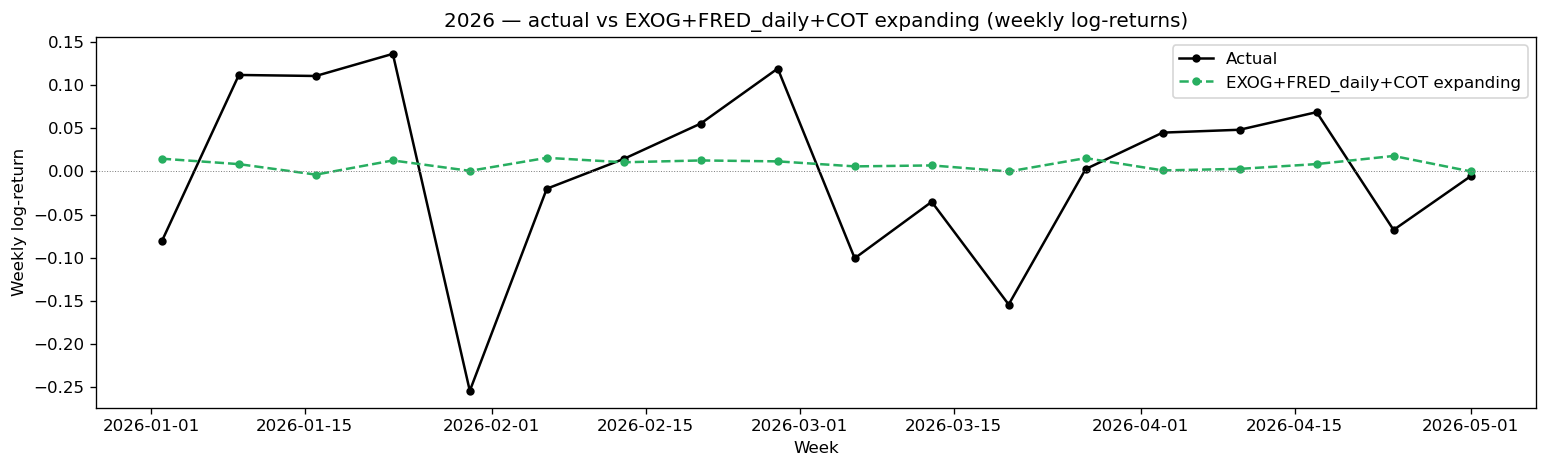

In [12]:
df26 = pd.DataFrame({"actual": y_test, "pred": best_pred}, index=test_index)
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#27ae60", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (weekly log-returns)", fontsize=12)
    ax.set_ylabel("Weekly log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()